In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, KFold
from sklearn.metrics import mean_squared_log_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor

cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [2]:
df = pd.read_csv('/train.csv')
df = df.drop('ID', axis = 1)
df.head()

,target,48df886f9,0deb4b6a8,34b15f335,a8cb14b00,2f0771a37,30347e683,d08d1fbe3,6ee66e115,20aa07010,...,3ecc09859,9281abeea,8675bec0b,3a13ed79a,f677d4d13,71b203550,137efaa80,fb36b89d9,7e293fbaf,9fc776466
0,38000000.0,0.0,0,0.0,0,0,0,0,0,0.0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
1,600000.0,0.0,0,0.0,0,0,0,0,0,2200000.0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
2,10000000.0,0.0,0,0.0,0,0,0,0,0,0.0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
3,2000000.0,0.0,0,0.0,0,0,0,0,0,0.0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
4,14400000.0,0.0,0,0.0,0,0,0,0,0,2000000.0,...,0.0,0.0,0.0,0,0,0,0,0,0,0


In [3]:
df.shape

(4459, 4992)

In [4]:
counter = {}
for key in df.keys():
    a = df[key].dtype
    counter[a] = counter.get(a, 0) + 1
counter

{dtype('float64'): 1845, dtype('int64'): 3147}

Все признаки числовые

In [5]:
Y = df['target']
Y_log = np.log1p(Y)
X = df.drop('target', axis=1)
Y.describe()

count    4.459000e+03
mean     5.944923e+06
std      8.234312e+06
min      3.000000e+04
25%      6.000000e+05
50%      2.260000e+06
75%      8.000000e+06
max      4.000000e+07
Name: target, dtype: float64

{'whiskers': [<matplotlib.lines.Line2D at 0x1523051d0>,
 'caps': [<matplotlib.lines.Line2D at 0x152305450>,
 'boxes': [<matplotlib.lines.Line2D at 0x1514c8f50>],
 'medians': [<matplotlib.lines.Line2D at 0x1523056d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x152305810>],
 'means': []}

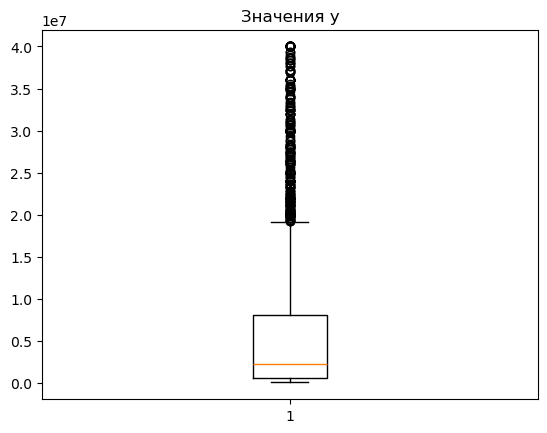

In [6]:
fig, axes = plt.subplots()
axes.set_title('Значения y')
axes.boxplot(Y)

Явных выбросов нет

In [7]:
to_drop = []
for col in X.columns:
    if X[col].nunique() == 1 or X[col].isna().all():
        to_drop.append(col)
X = X.drop(columns=to_drop)
X.shape

(4459, 4735)

Future Engineering 

In [8]:
X['n_zeros'] = (X == 0).sum(axis=1)
X['row_mean'] = X.mean(axis=1)
X['row_max'] = X.max(axis=1)
X['row_sum'] = X.sum(axis=1)

In [9]:
corr = X.corrwith(Y)
corr.abs().sort_values(ascending=False).head(10)

555f18bd3    0.273379
row_mean     0.271884
9fd594eec    0.270019
row_sum      0.268216
5bc7ab64f    0.267858
cbbc9c431    0.265005
f190486d6    0.263821
6b119d8ce    0.258290
f74e8f13d    0.257238
ac30af84a    0.256292
dtype: float64

Нет выделяющихся сильно коррелирующих с target признаков

Отбор признаков 

In [10]:
pipe_lgbm = Pipeline([
    ('select', SelectKBest(f_regression, k=300)),
    ('model', LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=5,
        random_state=42,
        verbose=-1,
        n_jobs=-1,
    ))
])

scores = cross_val_score(pipe_lgbm, X, Y_log, cv=cv, scoring='neg_root_mean_squared_error')
rmsle_scores = -scores

print(f"RMSLE по фолдам: {rmsle_scores}")
print(f"RMSLE: {rmsle_scores.mean():.4f} ± {rmsle_scores.std():.4f}")

RMSLE по фолдам: [1.40641884 1.46945934 1.44028004 1.44895788 1.42162931]
RMSLE: 1.4373 ± 0.0218


In [11]:
model_final = pipe_lgbm
model_final.fit(X, Y_log)

df_test = pd.read_csv('/test.csv')
test_ids = df_test['ID']

ROW_FEATS = ['n_zeros', 'row_mean', 'row_max', 'row_sum']
base_cols = [c for c in X.columns if c not in ROW_FEATS]

X_test = df_test[base_cols].copy()

X_test['n_zeros'] = (X_test[base_cols] == 0).sum(axis=1)
X_test['row_mean'] = X_test[base_cols].mean(axis=1)
X_test['row_max'] = X_test[base_cols].max(axis=1)
X_test['row_sum'] = X_test[base_cols].sum(axis=1)

X_test = X_test[X.columns]

print("train row_sum:", X['row_sum'].mean(), "| test row_sum:", X_test['row_sum'].mean())
print("train n_zeros:", X['n_zeros'].mean(), "| test n_zeros:", X_test['n_zeros'].mean())

pred_log = model_final.predict(X_test)
pred = np.expm1(pred_log)

submission = pd.DataFrame({'ID': test_ids, 'target': pred})
submission.to_csv('submission.csv', index=False)

train row_sum: 1479588170.0039494 | test row_sum: 797677599.6688739
train n_zeros: 4577.989683785602 | test n_zeros: 4666.052348911678


скор на kaggle : 1.47

In [12]:
select_model = LGBMRegressor(n_estimators=500, random_state=42, max_depth=6)
select_model.fit(X, Y_log)
important = pd.Series(select_model.feature_importances_, index=X.columns)

In [13]:
for k in [200, 500, 1000, 2000, 4740]:
    top_k = important.sort_values(ascending=False).index[:k]
    scores = cross_val_score(LGBMRegressor(n_estimators=300, random_state=42, verbose=-1, n_jobs=-1),
                               X[top_k], Y_log, cv=cv, scoring='neg_root_mean_squared_error')
    print(f"k={k}: RMSLE = {-scores.mean():.4f} ± {scores.std():.4f}")

k=200: RMSLE = 1.3718 ± 0.0184
k=500: RMSLE = 1.3586 ± 0.0206
k=1000: RMSLE = 1.3809 ± 0.0157
k=2000: RMSLE = 1.4083 ± 0.0150
k=4740: RMSLE = 1.4321 ± 0.0146


In [14]:
for k in [300, 400, 500]:
    top_k = important.sort_values(ascending=False).index[:k]
    scores = cross_val_score(LGBMRegressor(n_estimators=300, random_state=42, verbose=-1, n_jobs=-1),
                               X[top_k], Y_log, cv=cv, scoring='neg_root_mean_squared_error')
    print(f"k={k}: RMSLE = {-scores.mean():.4f} ± {scores.std():.4f}")

k=300: RMSLE = 1.3552 ± 0.0184
k=400: RMSLE = 1.3581 ± 0.0181
k=500: RMSLE = 1.3586 ± 0.0206


In [15]:
X_selected = X[important.sort_values(ascending=False).index[:300]]

In [16]:
model_cb = CatBoostRegressor(iterations=1000, learning_rate=0.02, depth=6, random_state=42, verbose=0)
model_xgb = XGBRegressor(n_estimators=1000, learning_rate=0.02, max_depth=5, random_state=42)

scores_xgb = cross_val_score(model_xgb, X_selected, Y_log, cv=cv, scoring='neg_root_mean_squared_error')
scores_cb = cross_val_score(model_cb, X_selected, Y_log, cv=cv, scoring='neg_root_mean_squared_error')
print(f"XGB: {-scores_xgb.mean():.4f}, CatBoost: {-scores_cb.mean():.4f}")

XGB: 1.3607, CatBoost: 1.3666


In [17]:
from sklearn.model_selection import cross_val_predict

pred_xgb = cross_val_predict(model_xgb, X_selected, Y_log, cv=cv)
pred_cb = cross_val_predict(model_cb, X_selected, Y_log, cv=cv)
pred_lgbm = cross_val_predict(pipe_lgbm, X_selected, Y_log, cv=cv)

preds_df = pd.DataFrame({'xgb': pred_xgb, 'cb': pred_cb, 'lgbm': pred_lgbm})
print(preds_df.corr())

           xgb        cb      lgbm
xgb   1.000000  0.963112  0.966922
cb    0.963112  1.000000  0.952383
lgbm  0.966922  0.952383  1.000000


Модели сильно коррелируют, нет большого смысла в стекинге

In [18]:
for k in [5, 10, 15, 20]:
    model_rf = RandomForestRegressor(n_estimators=150, random_state=42, max_depth=k, n_jobs=-1)
    pred_rf = cross_val_predict(model_rf, X_selected, Y_log, cv=cv)
    rmsle_rf = np.sqrt(mean_squared_error(Y_log, pred_rf))
    print(f'k = {k} : RMSLE = {rmsle_rf:.4f}')

k = 5 : RMSLE = 1.4792
k = 10 : RMSLE = 1.4121
k = 15 : RMSLE = 1.3960
k = 20 : RMSLE = 1.3923


In [19]:
for k in [30, 33, 36, 35]:
    model_rf = RandomForestRegressor(n_estimators=150, random_state=42, max_depth=k, n_jobs=-1)
    pred_rf = cross_val_predict(model_rf, X_selected, Y_log, cv=cv)
    rmsle_rf = np.sqrt(mean_squared_error(Y_log, pred_rf))
    print(f'k = {k} : RMSLE = {rmsle_rf:.4f}')

k = 30 : RMSLE = 1.3914
k = 33 : RMSLE = 1.3928
k = 36 : RMSLE = 1.3921
k = 35 : RMSLE = 1.3917


In [20]:
model_rf = RandomForestRegressor(n_estimators=500, random_state=42, max_depth=30, n_jobs=-1)
model_rf.fit(X_selected, Y_log)

pred_rf_final = cross_val_predict(model_rf, X_selected, Y_log, cv=cv)
rmsle_rf_final = np.sqrt(mean_squared_error(Y_log, pred_rf_final))
print(f"RF финальный RMSLE: {rmsle_rf_final:.4f}")

RF финальный RMSLE: 1.3886


In [21]:
preds_df = pd.DataFrame({'xgb': pred_xgb, 'cbt': pred_cb, 'lgbm': pred_lgbm, 'rf' : pred_rf_final})
print(preds_df.corr())

           xgb       cbt      lgbm        rf
xgb   1.000000  0.963112  0.966922  0.928378
cbt   0.963112  1.000000  0.952383  0.923421
lgbm  0.966922  0.952383  1.000000  0.921300
rf    0.928378  0.923421  0.921300  1.000000


все еще высокие corr, попробую добавить Lasso 

In [22]:
pipe_lasso = Pipeline([
    ('scale', StandardScaler()),
    ('model', LassoCV(cv=3, random_state=42, n_jobs=-1, max_iter=5000))
])
pred_lasso = cross_val_predict(pipe_lasso, X_selected, Y_log, cv=cv)
rmsle_lasso = np.sqrt(mean_squared_error(Y_log, pred_lasso))
print(f"Lasso RMSLE: {rmsle_lasso:.4f}")

Lasso RMSLE: 1.6279


In [23]:
preds_df['l1'] = pred_lasso
print(preds_df.corr())

           xgb       cbt      lgbm        rf        l1
xgb   1.000000  0.963112  0.966922  0.928378  0.557528
cbt   0.963112  1.000000  0.952383  0.923421  0.583491
lgbm  0.966922  0.952383  1.000000  0.921300  0.553299
rf    0.928378  0.923421  0.921300  1.000000  0.503635
l1    0.557528  0.583491  0.553299  0.503635  1.000000


In [24]:
stacker = LinearRegression(positive=True)
stacker.fit(preds_df, Y_log)
print(dict(zip(preds_df.columns, stacker.coef_)))

blend_stack = stacker.predict(preds_df)
rmsle_stack = np.sqrt(mean_squared_error(Y_log, blend_stack))
print(f"Stacking RMSLE: {rmsle_stack:.4f}")

{'xgb': np.float64(0.04291433988922991), 'cbt': np.float64(0.18866384309259387), 'lgbm': np.float64(0.64692255544707), 'rf': np.float64(0.14042679934441288), 'l1': np.float64(0.029962730488229953)}
Stacking RMSLE: 1.3402


In [25]:
X_selected.shape

(4459, 300)

In [26]:
final_preds_df = pd.DataFrame()
final_lgbm = pipe_lgbm
final_lgbm.fit(X_selected, Y_log)
final_preds_df['lgbm'] = final_lgbm.predict(X_test[X_selected.columns])

In [27]:
final_cbt = CatBoostRegressor(iterations=1000, learning_rate=0.02, depth=6, random_state=42, verbose=0)
final_cbt.fit(X_selected, Y_log)
final_preds_df['cbt'] = final_cbt.predict(X_test[X_selected.columns])

In [28]:
final_xgb = XGBRegressor(n_estimators=1000, learning_rate=0.02, max_depth=5, random_state=42)
final_xgb.fit(X_selected, Y_log)
final_preds_df['xgb'] = final_xgb.predict(X_test[X_selected.columns])

In [29]:
final_rf = RandomForestRegressor(n_estimators=500, random_state=42, max_depth=30, n_jobs=-1)
final_rf.fit(X_selected, Y_log)
final_preds_df['rf'] = final_rf.predict(X_test[X_selected.columns])

In [30]:
pipe_lasso.fit(X_selected, Y_log)
final_preds_df['l1'] = pipe_lasso.predict(X_test[X_selected.columns])

In [31]:
final_preds_df

,lgbm,cbt,xgb,rf,l1
0,14.964517,14.996193,15.081613,15.806670,14.285277
1,14.216687,14.632949,14.298247,14.141130,14.287292
2,14.837924,14.420327,14.559551,14.336439,14.384006
3,14.641554,14.931205,15.098801,14.985240,14.849185
4,14.216841,14.689658,14.630944,13.980936,14.289029
...,...,...,...,...,...
49337,14.377962,13.334193,12.936211,14.370132,14.155520
49338,15.831332,15.839435,16.087517,16.505124,15.111801
49339,13.620489,13.732054,13.717289,14.601364,11.577309
49340,13.594376,13.946966,13.738658,13.622445,14.255205


In [32]:
preds_df

,xgb,cbt,lgbm,rf,l1
0,14.934176,14.836735,15.393414,14.590483,14.501905
1,14.480768,14.361788,14.429572,14.195462,14.386399
2,14.800997,14.702028,14.809925,14.593841,14.338579
3,14.019658,14.031506,13.912043,13.857419,14.303285
4,14.944138,14.770188,14.843427,15.186407,14.719590
...,...,...,...,...,...
4454,13.521935,13.545241,13.434182,13.857759,14.224843
4455,11.483040,11.477803,11.700592,11.381275,14.108131
4456,14.702511,15.071633,14.474853,14.893249,14.452315
4457,13.984378,13.980192,14.074880,13.861358,14.274471


In [33]:
stacker = LinearRegression(positive=True)
stacker.fit(preds_df, Y_log)
print(dict(zip(preds_df.columns, stacker.coef_)))

blend_stack = stacker.predict(preds_df)
pred_log = stacker.predict(final_preds_df[preds_df.columns])   # <-- добавлено
pred = np.expm1(pred_log)

submission = pd.DataFrame({'ID': test_ids, 'target': pred})
submission.to_csv('submission.csv', index=False)

{'xgb': np.float64(0.04291433988922991), 'cbt': np.float64(0.18866384309259387), 'lgbm': np.float64(0.64692255544707), 'rf': np.float64(0.14042679934441288), 'l1': np.float64(0.029962730488229953)}
